In [1]:
import requests
import pandas as pd
import numpy as np
import json
import re
import nltk
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
nltk.download("stopwords", force = True)
nltk.download("punkt", force = True)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\holli\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\holli\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

## Constants

In [2]:
SELECTED_COLUMNS = ["object", "id", "name", "lang",
                    "released_at", "uri", "scryfall_uri", "layout",
                    "mana_cost", "cmc", "type_line", "oracle_text",
                    "color_identity", "keywords", "produced_mana", "legalities",
                    "games", "game_changer", "set_id", "set",
                    "set_name", "set_type", "rarity", "digital",
                    "artist", "textless", "power", "toughness",
                    "loyalty", "printed_name"] 

BASIC_LAND_TYPES = ["Forest", "Mountain", "Island", "Swamp", "Plains"]

CARD_LAYOUTS = ["normal", "adventure", "transform", "split",
                "modal_dfc", "planar", "reversilbe_card", "meld",                                                                                               
                "saga", "class", "case", "flip",
                "leveler", "prototype"]

CARD_TYPES = ["Land", "Legendary", "Artifact", "Enchantment", "Battle",
              "Instant", "Sorcery", "Creature", "Planeswalker", "Vanguard",
              "Kindred"]

CARD_SUBTYPES = ["Equipment", "Vehicle", "Powerstone", "Fortification", "Clue", 
                 "Bobblehead", "Food", "Key", "Treasure", "Aura",
                 "Saga", "Curse", "Room", "Background", "Class",
                 "Case", "Rune", "Shrine", "Siege", "Arcane",
                 "Trap", "Adventure", "Lesson", "Omen"]

RARITY = ["common", "uncommon", "rare", "mythic", "special"]

COLORS_DICT = {"blue": "U",
               "red": "R",
               "white": "W",
               "black": "B",
               "green": "G",
               "colorless": ""}

COLORS = ["blue", "red", "white", "black", "green"]

GAME_FORMATS = ["standard", "future", "historic",
                "timeless", "gladiator", "pioneer",
                "explorer", "modern", "legacy",
                "pauper", "vintage", "penny",
                "commander", "oathbreaker", "standardbrawl",
                "brawl", "alchemy", "paupercommander",
                "duel", "oldschool", "premodern", "predh"]

CARD_LAYOUT_KEEP = ["normal", "adventure", "transform", "split",
                    "modal_dfc", "planar", "reversilbe_card", "meld",
                    "saga", "class", "case", "flip",
                    "leveler", "prototype"]

NON_LEGAL_MAGIC_SETS = ["Unglued", "Unhinged", "Unstable", "Unsanctioned",
                        "Unfinity"]

COLOR_PIPS_DICT = {"blue": "U",
                   "red": "R",
                   "white": "W",
                   "black": "B",
                   "green": "G",
                   "colorless": "C"}

BATTLE_ATTRIBUTES = ["power", "toughness", "planeswalker_loyalty"]

DROP_COLUMNS = ["artist", "cmc", "color_identity",
                "games", "keywords", "lang",
                "layout", "legalities", "loyalty",
                "object", "printed_name", "produced_mana",
                "rarity", "released_at", "set",
                "set_id", "set_name", "set_type",
                "standard", "future", "historic",
                "timeless", "gladiator", "pioneer", 
                "explorer", "modern", "legacy", 
                "pauper", "vintage", "penny", 
                "commander", "oathbreaker", "standardbrawl", 
                "brawl", "alchemy", "paupercommander", 
                "duel", "oldschool", "premodern", 
                "predh", "legal_sum"]

SCRYFALL_CARDS_URL = "https://data.scryfall.io/default-cards/default-cards-20250413212519.json"

## Data Processing class

In [3]:
class MTGDataProcessor:
    
    def __init__(self, selected_columns, colors_dict, card_types, card_subtypes,
                 game_formats, non_legal_sets, basic_lands, card_layout_keep,
                 color_pips_dict, rarity, drop_columns, battle_attributes):
        
        self.selected_columns = selected_columns
        self.colors_dict = colors_dict
        self.card_types = card_types
        self.card_subtypes = card_subtypes
        self.game_formats = game_formats
        self.non_legal_sets = non_legal_sets
        self.basic_lands = basic_lands
        self.card_layout_keep = card_layout_keep
        self.color_pips_dict = color_pips_dict
        self.rarity = rarity
        self.drop_columns = drop_columns
        self.battle_attributes = battle_attributes
        self.df = None
        
    def get_url_data(self, url):

        request_response = requests.get(url)
        if request_response.status_code == 200:
            return request_response.json()
        else:
            return request_response.status_code
    
    def json_to_dataframe(self, json_data):
        
        if isinstance(json_data, list):
            return pd.DataFrame(json_data)
        elif isinstance(json_data, dict):
            return pd.DataFrame([json_data])
        else:
            return pd.DataFrame([json_data])
    
    def load_data(self, url):
        
        json_data = self.get_url_data(url)
        self.df = self.json_to_dataframe(json_data)
        
    
    def filter_tokens_and_basic_lands(self):
        
        df_clean = self.df.copy()
        
        df_clean = df_clean[self.selected_columns]

        # Filter for English only cards and non tokens and digital only and filter out basic lands
        df_clean = df_clean.loc[(df_clean.layout.isin(self.card_layout_keep)) &
                                ~(df_clean.name.isin(self.basic_lands)) &
                                ~(df_clean.set_name.isin(self.non_legal_sets)) &
                                (df_clean["digital"] == False)]
        self.df = df_clean
        
    def clean_combat_stat(self, value):
        
        if value is None or (isinstance(value, float) and np.isnan(value)):
            
            return None
        
        inf_stat = bool(re.search(pattern = r"\*", string = value))
        
        if inf_stat:
            
            return np.inf
        
        else:
            
            return int(value)
        
        
    def clean_power_and_toughness(self):
        
        df_clean = self.df.copy()
        
        df_clean["power"] = df_clean["power"].apply(self.clean_combat_stat)
        df_clean["toughness"] = df_clean["toughness"].apply(self.clean_combat_stat)
        
        self.df = df_clean
        
    def is_color(self):
    
        df_clean = self.df.copy()
        
        for color, color_char in self.colors_dict.items():
        
            if color in ["blue", "red", "white", "black", "green"]:

                df_clean.loc[:, f"is_{color}"] = df_clean["color_identity"].apply(
                    lambda x: color_char in x if isinstance(x, list) else False
                ).astype("boolean") 
            
                df_clean.loc[df_clean["color_identity"].isna(), f"is_{color}"] = None
            
                df_clean[f"produced_{color}"] = df_clean["produced_mana"].apply(
                lambda x: color_char in x if isinstance(x, list) else False
                ).astype("boolean")
            
                df_clean.loc[df_clean["produced_mana"].isna(), f"produced_{color}"] = None
            
            else:  # This is for colorless
            
                df_clean.loc[:, f"is_{color}"] = df_clean["color_identity"].apply(
                    lambda x: len(x) == 0 if isinstance(x, list) else False
                    ).astype("boolean")
            
                df_clean.loc[df_clean["color_identity"].isna(), f"is_{color}"] = None
            
                df_clean[f"produced_{color}"] = df_clean["produced_mana"].apply(
                    lambda x: "C" in x if isinstance(x, list) else False
                    ).astype("boolean")
            
                df_clean.loc[df_clean["produced_mana"].isna(), f"produced_{color}"] = None
            
        self.df = df_clean
        
    def is_in_format(self):
        
        df_clean = self.df.copy()
        
        df_clean = pd.concat([df_clean,
                              (df_clean["legalities"].apply(pd.Series))],
                               axis = 1,
                               ignore_index = False).reset_index(drop = True)
        
        all_games = set([game for sublist in df_clean["games"] for game in sublist])
        
        for current_game in all_games:
            
            df_clean[f"is_in_{current_game}"] = df_clean["games"].apply(
                
                lambda x: current_game in x if isinstance(x, list) else False
                
                ).astype("boolean")
            
            df_clean.loc[df_clean["games"].isna(), f"is_in_{current_game}"] = None
            
        self.df = df_clean
        
    
    def is_card_type(self):
        
        df_clean = self.df.copy()
        
        for card_type in self.card_types:
            
            has_card_type = df_clean["type_line"].str.contains(
                
                card_type, na = False, regex = True
                
            )
            
            df_clean[f"is_{card_type}"] = None
            df_clean.loc[has_card_type, f"is_{card_type}"] = True
            df_clean.loc[~has_card_type, f"is_{card_type}"] = False
            
            
        for card_subtype in self.card_subtypes:
            
            has_card_type = df_clean["type_line"].str.contains(
                
                card_subtype, na = False, regex = True
    
            )
            
            df_clean[f"is_{card_subtype}"] = None
            df_clean.loc[has_card_type, f"is_{card_subtype}"] = True
            df_clean.loc[~has_card_type, f"is_{card_subtype}"] = False
            
        self.df = df_clean
        
    def get_rarity(self):
        
        df_clean = self.df.copy()

        for rarity_level in self.rarity:
            # Start with all NA
            df_clean[f"is_{rarity_level}"] = None
        
            # Set True where rarity matches
            df_clean.loc[df_clean["rarity"] == rarity_level, f"is_{rarity_level}"] = True
        
            # Set False where rarity exists but doesn't match
            not_na_mask = df_clean["rarity"].notna()
            not_match_mask = df_clean["rarity"] != rarity_level
            df_clean.loc[not_na_mask & not_match_mask, f"is_{rarity_level}"] = False
        
            # Ensure boolean type
            df_clean[f"is_{rarity_level}"] = df_clean[f"is_{rarity_level}"].astype("boolean")
    
        self.df = df_clean
    
    def create_subtype(self):
        
        df_clean = self.df.copy()
        
        df_clean[["card_type", "card_subtype"]] = df_clean["type_line"].str.split(pat = "—", n = 1, expand = True)
        
        df_clean["card_type"] = df_clean["card_type"].str.strip()
        df_clean["card_subtype"] = df_clean["card_subtype"].str.strip()

        card_subtype_na_mask = df_clean["card_subtype"].isna()

        # fill na card_subtype with the main card_type
        df_clean["card_subtype"] = df_clean["card_subtype"].fillna(df_clean.loc[card_subtype_na_mask, "card_type"])
        
        self.df = df_clean
        
    def create_keyword_string(self):
        
        df_clean = self.df.copy()
        
        df_clean["keywords_string"] = df_clean["keywords"].apply(
            lambda x: ", ".join(x) if isinstance(x, list) and len(x) > 0 else None)
        
        self.df = df_clean
        
    def create_legalities(self):  
        
        df_clean = self.df.copy()
        
        for game in self.game_formats:
            
            game_string = "_".join([game, "legal"])
            
            df_clean[game_string] = None
            
            df_clean.loc[df_clean[game] == "legal", game_string] = True
            df_clean.loc[df_clean[game] == "not_legal", game_string] = False
            df_clean.loc[df_clean[game] == "banned", game_string] = False
            
            df_clean.loc[df_clean[game].isna(), game_string] = None
        
        self.df = df_clean
        
    def count_number_of_color_pips(self):
        
        df_output = self.df.copy()
        
        df_output["mana_cost"] = df_output["mana_cost"].apply(lambda x: re.sub(pattern = r"[{}]",  repl = "", string = str(x)))
        
        for color, color_char in self.color_pips_dict.items():
            
            df_output[f"{color}_pips"] = df_output["mana_cost"].apply(lambda x: len(re.findall(re.escape(color_char), str(x))))
            
        df_output["generic_pips"] = df_output["mana_cost"].apply(lambda x: sum(int(d) for d in re.findall(r"\d+", str(x))))
        
        df_output["generic_pips"] = np.select(
            
            condlist = [df_output["mana_cost"].apply(lambda x: bool(re.search(r"X", str(x)))),
                        df_output["mana_cost"].isna()],
            choicelist = [np.inf, None],
            default = df_output["generic_pips"]
            
        )
        
        df_output["total_pips"] = (df_output["generic_pips"] +
                                   df_output["blue_pips"] +
                                   df_output["red_pips"] +
                                   df_output["black_pips"] +
                                   df_output["white_pips"] +
                                   df_output["green_pips"] +
                                   df_output["colorless_pips"])
        
        self.df = df_output
        
    def extract_planeswalker_loyalty(self, value): 
        
        if value is None or (isinstance(value, float) and np.isnan(value)):
        
            return None

        value = str(value)

        match = re.search(r"(\d+|X)", value)
        
        if match:
            
            token = match.group(1)
        
        if token == "X":
            
            return np.inf
        
        else:

            return int(token)

        return None
        
    def planeswalker_loyalty(self):
        
        df_clean = self.df.copy()

        df_clean["planeswalker_loyalty"] = df_clean["loyalty"].apply(self.extract_planeswalker_loyalty) 
        
        self.df = df_clean

    def get_number_of_splits(self, df, column_name):
        
        df_clean = df.copy()
        
        df_clean["number_of_splits"] = df_clean[column_name].apply(
            
            lambda x: len(re.findall(pattern = r"//", string = str(x))),
            
        )
        
        return max(df_clean["number_of_splits"]) + 1
    
    def split_types(self):
        
        df_clean = self.df.copy()
            
        colnames_to_split = ["card_name", "mana_cost", "type_line"]        
        df_clean = df_clean.rename(columns = {"name" : "card_name"})
        
        for col_name in colnames_to_split:
            
            number_of_splits = self.get_number_of_splits(df_clean, col_name)
            
            number_of_splits_list = [f"{col_name}-{i}" for i in range(1, number_of_splits + 1)]
                
            df_clean_split = df_clean[col_name].str.split("//", expand = True)
            df_clean_split.columns = number_of_splits_list
            
            df_clean = pd.concat([df_clean, df_clean_split], axis = 1).reset_index(drop = True)
            
        df_clean = df_clean.drop(colnames_to_split, axis = 1)
            
        self.df = df_clean
        
    def pivot_longer_double_cards(self):
        
        df_clean = self.df
        
        pivot_columns = df_clean.columns[df_clean.columns.str.contains(
            
            "card_name-\d+|mana_cost-\d+|type_line-\d+")].tolist()
        
        pivot_columns = list(set([re.sub(pattern = r"-\d+", string = col, repl = "") for col in pivot_columns]))
        
        df_clean = pd.wide_to_long(df_clean, pivot_columns, i = "id", 
                                   j = "card_sub", sep = "-")
        
        df_clean = df_clean.reset_index()
        
        self.df = df_clean
        
    def drop_non_legal_cards(self):
        
        df_clean = self.df.copy()
        
        legal_columns = [current_col for current_col in df_clean.columns if bool(re.search(pattern = r"_legal$",
                                                                                           string = current_col))]
        
        temp = df_clean[legal_columns]
        temp = temp.fillna(False).astype(int)
        
        df_clean["legal_sum"] = temp.sum(axis = 1)
        
        self.df = df_clean[df_clean["legal_sum"] != 0]
        
    def drop_unnecessary_columns(self):
        
        df_clean = self.df.copy()
        df_clean = df_clean.drop(self.drop_columns, axis = 1)
        df_clean.columns = [current_col.lower() for current_col in df_clean.columns]
        self.df = df_clean
        
    def make_data_unique(self):
        
        df_clean = self.df.copy()
        
        df_clean = df_clean.groupby("card_name").head(1).reset_index(drop = True)
        
        self.df = df_clean
        

    def process_data(self):
        
        """Run the full processing pipeline"""
        if self.df is None:
            
            raise ValueError("No data loaded. Call load_data() first.")
        
        self.filter_tokens_and_basic_lands()
        self.split_types()
        self.pivot_longer_double_cards()
        self.is_color()
        self.is_in_format()
        self.is_card_type()
        self.get_rarity()
        self.create_keyword_string()
        self.create_legalities()
        self.count_number_of_color_pips()
        self.create_subtype()
        self.drop_non_legal_cards()
        self.clean_power_and_toughness()
        self.planeswalker_loyalty()
        self.drop_unnecessary_columns()
        self.make_data_unique()
        print("Dataframe returned")

## Card Recommendation Class

In [7]:
class CardRecommenderModel:
    
    def __init__(self, data_processor):
        
        self.data_processor = data_processor
        self.stopwords = set(stopwords.words("english"))
        self.orcale_text_model = None 
        self.keyword_text_model = None 
        self.valid_game_format = None
                    
    def legal_cards_for_format(self, game_format = "Commander"):

        self.valid_game_format = game_format.strip().lower()

        if self.valid_game_format in self.data_processor.game_formats:
            
            self.data_processor.df = self.data_processor.df[self.data_processor.df[f"{self.valid_game_format}_legal"] == True].reset_index(drop = True)
        else:

            raise ValueError("Attempting to pass non-legal game format")
    
    def tokenize_text(self):
        
        self.data_processor.df["oracle_text_tokens"] = self.data_processor.df["oracle_text"].apply(self.tokenize_words)
        self.data_processor.df["keywords_string_tokens"] = self.data_processor.df["keywords_string"].apply(self.tokenize_words)
        self.data_processor.df["card_name_tokens"] = self.data_processor.df["card_name"].apply(self.tokenize_words)
        self.data_processor.df["card_subtype_tokens"] = self.data_processor.df["card_subtype"].apply(self.tokenize_words)
        
    def tokenize_words(self, text):
        
        if not text or pd.isna(text):
            
            return []
        
        else: 
            
            token = word_tokenize(text.lower()) 
            filtered_token = [word for word in token if word not in self.stopwords] 
            return filtered_token
        
    def trainWord2Vec_model(self):

        self.oracle_text_model = Word2Vec(sentences = self.data_processor.df["oracle_text_tokens"],
                                          vector_size = 100,
                                          window = 5, 
                                          min_count = 1, 
                                          workers = 4,
                                          seed = 99)
        
        self.keywords_string_model = Word2Vec(sentences = self.data_processor.df["keywords_string_tokens"],
                                            vector_size = 50,
                                            window = 5, 
                                            min_count = 1, 
                                            workers = 4,
                                            seed = 99)
        
        self.card_name_model = Word2Vec(sentences = self.data_processor.df["card_name_tokens"],
                                             vector_size = 40,
                                             window = 5, 
                                             min_count = 1, 
                                             workers = 4,
                                             seed = 99)
        
        self.card_subtype_model = Word2Vec(sentences = self.data_processor.df["card_subtype_tokens"],
                                           vector_size = 40,
                                           window = 5,
                                           min_count = 1,
                                           workers = 4,
                                           seed = 99)
        
    def average_word_vector_to_df(self):
        
        self.data_processor.df["oracle_text_avg_vec"] = self.data_processor.df["oracle_text_tokens"].apply(
            
            lambda x: self.get_average_word_vector(self.oracle_text_model, x)
            
            )
        
        self.data_processor.df["keywords_string_avg_vec"] = self.data_processor.df["keywords_string_tokens"].apply(
            
            lambda x: self.get_average_word_vector(self.keywords_string_model, x)
            
            )
        
        self.data_processor.df["card_name_avg_vec"] = self.data_processor.df["card_name_tokens"].apply(
            
            lambda x: self.get_average_word_vector(self.card_name_model, x)
            
            )
        
        self.data_processor.df["card_subtype_avg_vec"] = self.data_processor.df["card_subtype_tokens"].apply(
            
            lambda x: self.get_average_word_vector(self.card_subtype_model, x)
            
            )
        
    def get_average_word_vector(self, model, text_vec):
        
        if text_vec == []:
            
            return np.zeros(model.vector_size)
        
        else: 
            
            word_vec = [model.wv[word] for word in text_vec if word in model.wv.key_to_index] 
            
            if word_vec:
                
                return np.mean(word_vec, axis = 0)
            
            else:
                
                return np.zeros(model.vector_size)
    
    def get_model_inputs(self):
        
        # color columns
        is_color = ["is_" + color for color in list(self.data_processor.colors_dict)]
        produced_color = ["produced_" + color for color in list(self.data_processor.colors_dict)]
        
        color_pips = [color + "_pips" for color in list(self.data_processor.colors_dict)]
        
        primary_card_type = ["is_" + card_type.lower() for card_type in self.data_processor.card_types]
        secondary_card_type = ["is_" + card_subtype.lower() for card_subtype in self.data_processor.card_subtypes]
        
        rarity_type = ["is_" + rarity.lower() for rarity in self.data_processor.rarity]
        
        battle_attributes_type = self.data_processor.battle_attributes
        
        color_type_features = is_color + produced_color
        
        self.standardscaler = StandardScaler()
        
        self.color_type_features = self.data_processor.df[color_type_features].fillna(False).astype(int).values
        
        self.color_pips_features = self.data_processor.df[color_pips].fillna(0).values
        self.color_pips_features = np.nan_to_num(x = self.color_pips_features,
                                                 nan = -1,
                                                 posinf = 1e6,
                                                 neginf = -1e6)
        
        self.color_pips_features = self.standardscaler.fit_transform(self.color_pips_features)
        
        self.color_features = np.hstack([self.color_type_features, 
                                         self.color_pips_features])
        
        self.primary_card_type_features = self.data_processor.df[primary_card_type].fillna(False).astype(int).values
        self.secondary_card_type_features = self.data_processor.df[secondary_card_type].fillna(False).astype(int).values
        
        self.rarity_features = self.data_processor.df[rarity_type].fillna(False).astype(int).values
        
        self.battle_features = self.data_processor.df[battle_attributes_type].values
        self.battle_features = np.nan_to_num(x = self.battle_features,
                                             nan = -1,
                                             posinf = 1e6,
                                             neginf = -1e6)
        
        self.battle_features = self.standardscaler.fit_transform(self.battle_features)
        
        # oracle_features
        self.oracle_features = np.stack(self.data_processor.df["oracle_text_avg_vec"].values, axis = 0)
        self.oracle_features = self.standardscaler.fit_transform(self.oracle_features)
        
        # keyword features
        self.keyword_features = np.stack(self.data_processor.df["keywords_string_avg_vec"].values, axis = 0)
        self.keyword_features = self.standardscaler.fit_transform(self.keyword_features)
        
        # card name features
        self.card_name_features = np.stack(self.data_processor.df["card_name_avg_vec"].values, axis = 0)
        self.card_name_features = self.standardscaler.fit_transform(self.card_name_features)
        
        # card subtype features
        self.card_subtype_features = np.stack(self.data_processor.df["card_subtype_avg_vec"].values, axis = 0)
        self.card_subtype_features = self.standardscaler.fit_transform(self.card_subtype_features)
        
        self.binary_features = np.hstack([self.color_type_features,
                                          self.primary_card_type_features,
                                          self.secondary_card_type_features,
                                          self.rarity_features])
        
        self.numerical_features = np.hstack([self.color_pips_features, 
                                             self.battle_features])

        self.model_features = np.concatenate([self.binary_features,
                                              self.numerical_features,
                                              self.oracle_features,
                                              self.keyword_features,
                                              self.card_subtype_features,
                                              self.card_name_features],
                                              axis = 1)
        
        self.scaled_model_features = np.concatenate([self.binary_features * .3,
                                                     self.numerical_features * .15,
                                                     self.oracle_features * .3,
                                                     self.keyword_features * .12,
                                                     self.card_subtype_features * .08,
                                                     self.card_name_features * .05],
                                                     axis = 1)
        
        self.feature_names = (color_type_features +  primary_card_type +
                              secondary_card_type + rarity_type + 
                              color_pips + battle_attributes_type +
                              [f"ocacle_feature_{i}" for i in range(1, 101)] +
                              [f"keyword_feature_{i}" for i in range(1, 51)] + 
                              [f"card_subtype_features{i}" for i in range(1, 41)] +
                              [f"card_name_feature_{i}" for i in range(1, 41)])

        
    def train_KNN_model(self, neighbors = 6, n_features = 50):
        
        self.pca_model = PCA(n_components = n_features, random_state = 99)  # Reduce dimensions significantly
        self.scaled_model_features_pca = self.pca_model.fit_transform(self.scaled_model_features)
        self.unscaled_model_features_pca = self.pca_model.fit_transform(self.model_features)
        
        self.knn_model_scaled = NearestNeighbors(n_neighbors = neighbors, algorithm = "ball_tree").fit(self.scaled_model_features_pca)
        self.knn_model_unscaled = NearestNeighbors(n_neighbors = neighbors, algorithm = "ball_tree").fit(self.unscaled_model_features_pca)
    
    def find_nearest_neighbor_scaled(self, user_card_name):
        
        user_card_name = user_card_name.lower().strip()
        
        card_match = self.data_processor.df[self.data_processor.df["card_name"].str.lower() == user_card_name]
        
        if card_match.empty:
            
            print(f"{user_card_name} not found")
            return None

        input_card_index = self.data_processor.df[self.data_processor.df["card_name"].str.lower() == user_card_name].index[0]
        input_card_features = self.scaled_model_features_pca[input_card_index].reshape(1, -1)
        
        distances, indices = self.knn_model_scaled.kneighbors(input_card_features)
        
        input_card_info = self.data_processor.df.iloc[input_card_index, :]
        
        print(f"\nInput Card: {input_card_info['card_name']}")
        print(f"\nCard Type: {input_card_info['card_type']}")
        print(f"\nMana Cost: {input_card_info.get('mana_cost', 'No Mana Cost')}")
        print(f"\nOracle Text: {input_card_info.get('oracle_text', 'No Oracle Text')}")
        print("\n" + "=" * 60)
        print("RECOMMENDED CARDS")
        
        recommendations_data = self.data_processor.df.loc[indices[0], ].reset_index()
        recommendations_data = recommendations_data.iloc[1: ]
        
        for index, row in recommendations_data.iterrows():
            
            print(f"\nRecommended Card {index}: {row['card_name']}")
            print(f"\nCard Type {index}: {row['card_type']}")
            print(f"\nMana Cost: {index}: {row['mana_cost']}")
            print(f"\nOracle Text: {index}: {row['oracle_text']}")
            print("\n" + "=" * 60)

    def find_nearest_neighbor_unscaled(self, user_card_name):
        
        user_card_name = user_card_name.lower().strip()
        
        card_match = self.data_processor.df[self.data_processor.df["card_name"].str.lower() == user_card_name]
        
        if card_match.empty:
            
            print(f"{user_card_name} not found")
            return None

        input_card_index = self.data_processor.df[self.data_processor.df["card_name"].str.lower() == user_card_name].index[0]
        input_card_features = self.scaled_model_features_pca[input_card_index].reshape(1, -1)
        
        distances, indices = self.knn_model_unscaled.kneighbors(input_card_features)
        
        input_card_info = self.data_processor.df.iloc[input_card_index, :]
        
        print(f"\nInput Card: {input_card_info['card_name']}")
        print(f"\nCard Type: {input_card_info['card_type']}")
        print(f"\nMana Cost: {input_card_info.get('mana_cost', 'No Mana Cost')}")
        print(f"\nOracle Text: {input_card_info.get('oracle_text', 'No Oracle Text')}")
        print("\n" + "=" * 60)
        print("RECOMMENDED CARDS")
        
        recommendations_data = self.data_processor.df.loc[indices[0], ].reset_index()
        recommendations_data = recommendations_data.iloc[1: ]
        
        for index, row in recommendations_data.iterrows():
            
            print(f"\nRecommended Card {index}: {row['card_name']}")
            print(f"\nCard Type {index}: {row['card_type']}")
            print(f"\nMana Cost: {index}: {row['mana_cost']}")
            print(f"\nOracle Text: {index}: {row['oracle_text']}")
            print("\n" + "=" * 60)
        
    def train_kmeans_model(self, n_clusters = 8):
        
        self.kmeans_model = KMeans(n_clusters = n_clusters, random_state = 99)
        self.cluster_names = self.kmeans_model.fit_predict(self.unscaled_model_features_pca)
            
    def tsne_data_visualization(self, n_components = 2):
        
        self.tsne_model = TSNE(n_components = n_components, random_state = 99)
        self.tsne_features = self.tsne_model.fit_transform(self.unscaled_model_features_pca)
        
        plt.figure(figsize = (12, 8))

        for cluster in np.unique(self.cluster_names):

            cluster_mask = self.cluster_names == cluster
            
            self.tsne_scatter = plt.scatter(self.tsne_features[cluster_mask, 0], self.tsne_features[cluster_mask, 1],
                                            label = f"Cluster {cluster}")
        
        plt.title("MTG Cards Clusters by K-Means")
        plt.xlabel("t-SNE Component 1")
        plt.ylabel("t-SNE Component 2")
        plt.legend()
        
        # add a few card names to the plot
        sample_card_data = self.data_processor.df.sample(25, replace = False)
        sample_card_indices = sample_card_data.index.tolist()
        
        for index in sample_card_indices:
            
            plt.annotate(self.data_processor.df.loc[index, "card_name"],
                         (self.tsne_features[index, 0], self.tsne_features[index, 1]))
            
        plt.tight_layout()
        plt.show()
        
    def analyze_clusters(self):
        
        self.data_processor.df["cluster"] = self.cluster_names
        
        self.card_type_by_cluster = self.data_processor.df.groupby("cluster")["card_type"].value_counts().reset_index()
        self.card_type_by_cluster = self.card_type_by_cluster.sort_values(by = ["cluster", "count"], ascending = [True, False])
        self.card_type_by_cluster = self.card_type_by_cluster.groupby("cluster").head(5).reset_index(drop = True)
        
        self.card_subtype_by_cluster = self.data_processor.df.groupby("cluster")["card_subtype"].value_counts().reset_index()
        self.card_subtype_by_cluster = self.card_subtype_by_cluster.sort_values(by = ["cluster", "count"], ascending = [True, False])
        self.card_subtype_by_cluster = self.card_subtype_by_cluster.groupby("cluster").head(5).reset_index(drop = True)

        self.color_by_cluster = self.data_processor.df.groupby("cluster").agg({
            
            "is_blue" : "sum",
            "is_red" : "sum",
            "is_black" : "sum",
            "is_green" : "sum",
            "is_white" : "sum",
            "is_colorless" : "sum"
            
        })


    def RandomForest_for_clusters(self):

        X = self.model_features
        y = self.cluster_names

        self.rf_cluster_model = RandomForestClassifier(n_estimators = 100, random_state = 99)
        self.rf_cluster_model.fit(X, y)

    def random_forest_feature_importance_visualization(self):

        self.rf_cluster_model_feature_importance = self.rf_cluster_model.feature_importances_

        indices = np.argsort(self.rf_cluster_model_feature_importance)[::-1][:20]
        plt.figure(figsize = (12, 6))
        self.feature_importance_bar_graph = plt.barh(range(20), self.rf_cluster_model_feature_importance[indices])
        plt.yticks(range(20), [self.feature_names[i] for i in indices])
        plt.xlabel("Feature Importance")
        plt.title("Feature Importance for Card Recommender Model")
        plt.tight_layout()
        plt.show()

    def plot_card_type_clusters(self):

        cluster = 0

        fig, axs = plt.subplots(2, 4, figsize = (15, 15))
        fig.suptitle("Most Common Card Type by Cluster")

        for i in range(2):
            for j in range(4):

                cluster_mask = self.card_type_by_cluster["cluster"] == cluster
                cluster_values = self.card_type_by_cluster.loc[cluster_mask]
            
                axs[i, j].bar(cluster_values["card_type"], cluster_values["count"])
                axs[i, j].set_title(f"Cluster {cluster} Most Common Card Type")
                axs[i, j].set_xticklabels(cluster_values["card_type"], rotation = 90)
                axs[i, j].set_ylabel("Count")

                cluster = cluster + 1

        fig.tight_layout()
        plt.show()   

    def plot_card_subtype_clusters(self):

        cluster = 0

        fig, axs = plt.subplots(2, 4, figsize = (15, 15))
        fig.suptitle("Most Common Card Subtype by Cluster")

        for i in range(2):
            for j in range(4):

                cluster_mask = self.card_subtype_by_cluster["cluster"] == cluster
                cluster_values = self.card_subtype_by_cluster.loc[cluster_mask]
            
                axs[i, j].bar(cluster_values["card_subtype"], cluster_values["count"])
                axs[i, j].set_title(f"Cluster {cluster} Most Common Card Subtype")
                axs[i, j].set_xticklabels(cluster_values["card_subtype"], rotation = 90)
                axs[i, j].set_ylabel("Count")

                cluster = cluster + 1

        fig.tight_layout()
        plt.show()  

    def train_models(self):

        self.legal_cards_for_format()
        self.tokenize_text()
        self.trainWord2Vec_model()
        self.average_word_vector_to_df()
        self.get_model_inputs()
        self.train_KNN_model()
        self.train_kmeans_model()
        self.RandomForest_for_clusters()
        

## Clean Raw Data

In [8]:
processor = MTGDataProcessor(
    
    selected_columns = SELECTED_COLUMNS,
    colors_dict = COLORS_DICT,
    card_types = CARD_TYPES,
    card_subtypes = CARD_SUBTYPES,
    game_formats = GAME_FORMATS,
    non_legal_sets = NON_LEGAL_MAGIC_SETS,
    basic_lands = BASIC_LAND_TYPES,
    card_layout_keep = CARD_LAYOUT_KEEP,
    color_pips_dict = COLOR_PIPS_DICT,
    rarity = RARITY,
    drop_columns = DROP_COLUMNS,
    battle_attributes = BATTLE_ATTRIBUTES
)

processor.load_data(SCRYFALL_CARDS_URL)
processor.process_data()

C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3004573721.py:360: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp = temp.fillna(False).astype(int)


Dataframe returned


## Train Card Models

In [9]:
card_training_model = CardRecommenderModel(processor)
card_training_model.train_models()

C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:147: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.primary_card_type_features = self.data_processor.df[primary_card_type].fillna(False).astype(int).values
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:148: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.secondary_card_type_features = self.data_processor.df[secondary_card_type].fillna(False).astype(int).values


## Data Analysis on Clusters

C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:386: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_type"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:386: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_type"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:386: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_type"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:386: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

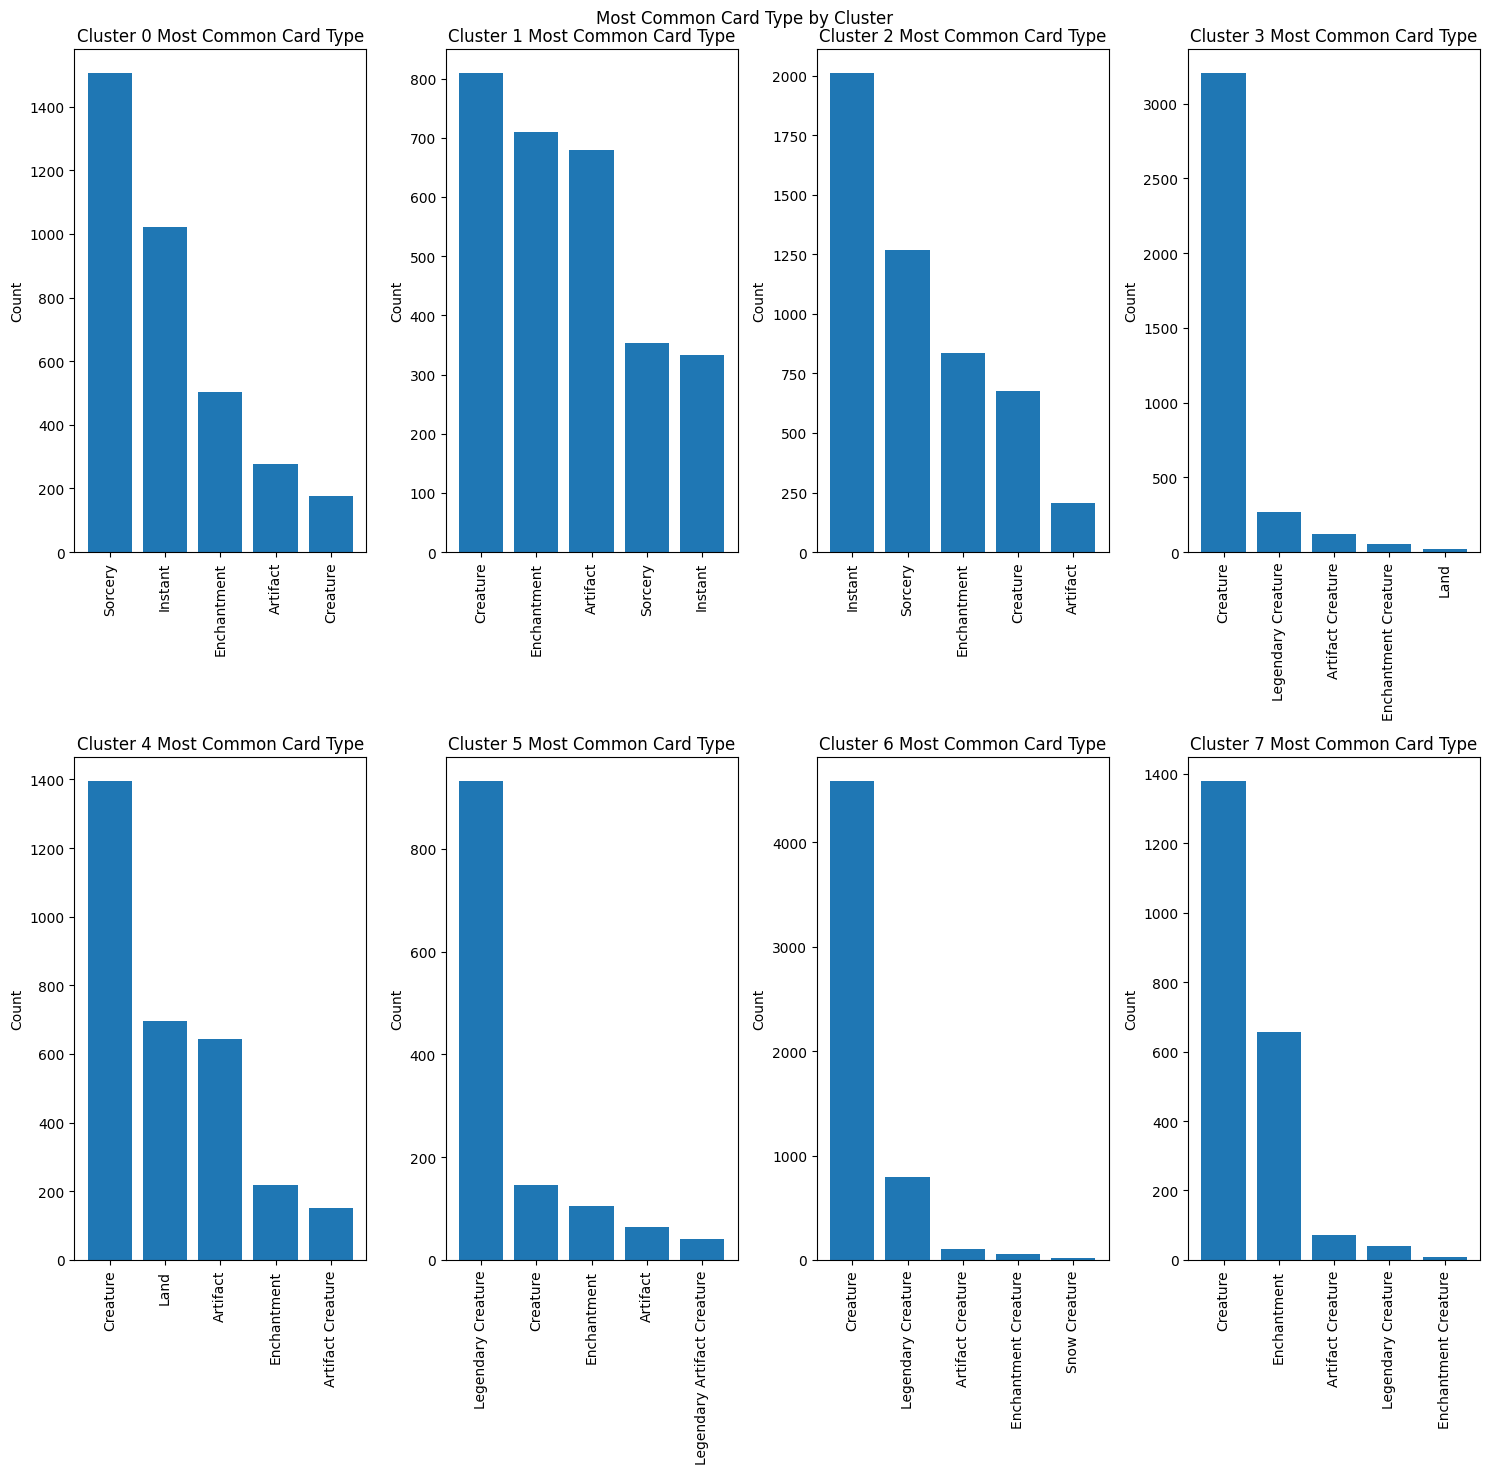

In [10]:
card_training_model.analyze_clusters()
card_training_model.plot_card_type_clusters()

C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:409: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_subtype"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:409: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_subtype"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:409: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i, j].set_xticklabels(cluster_values["card_subtype"], rotation = 90)
C:\Users\holli\AppData\Local\Temp\ipykernel_12064\3855185517.py:409: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

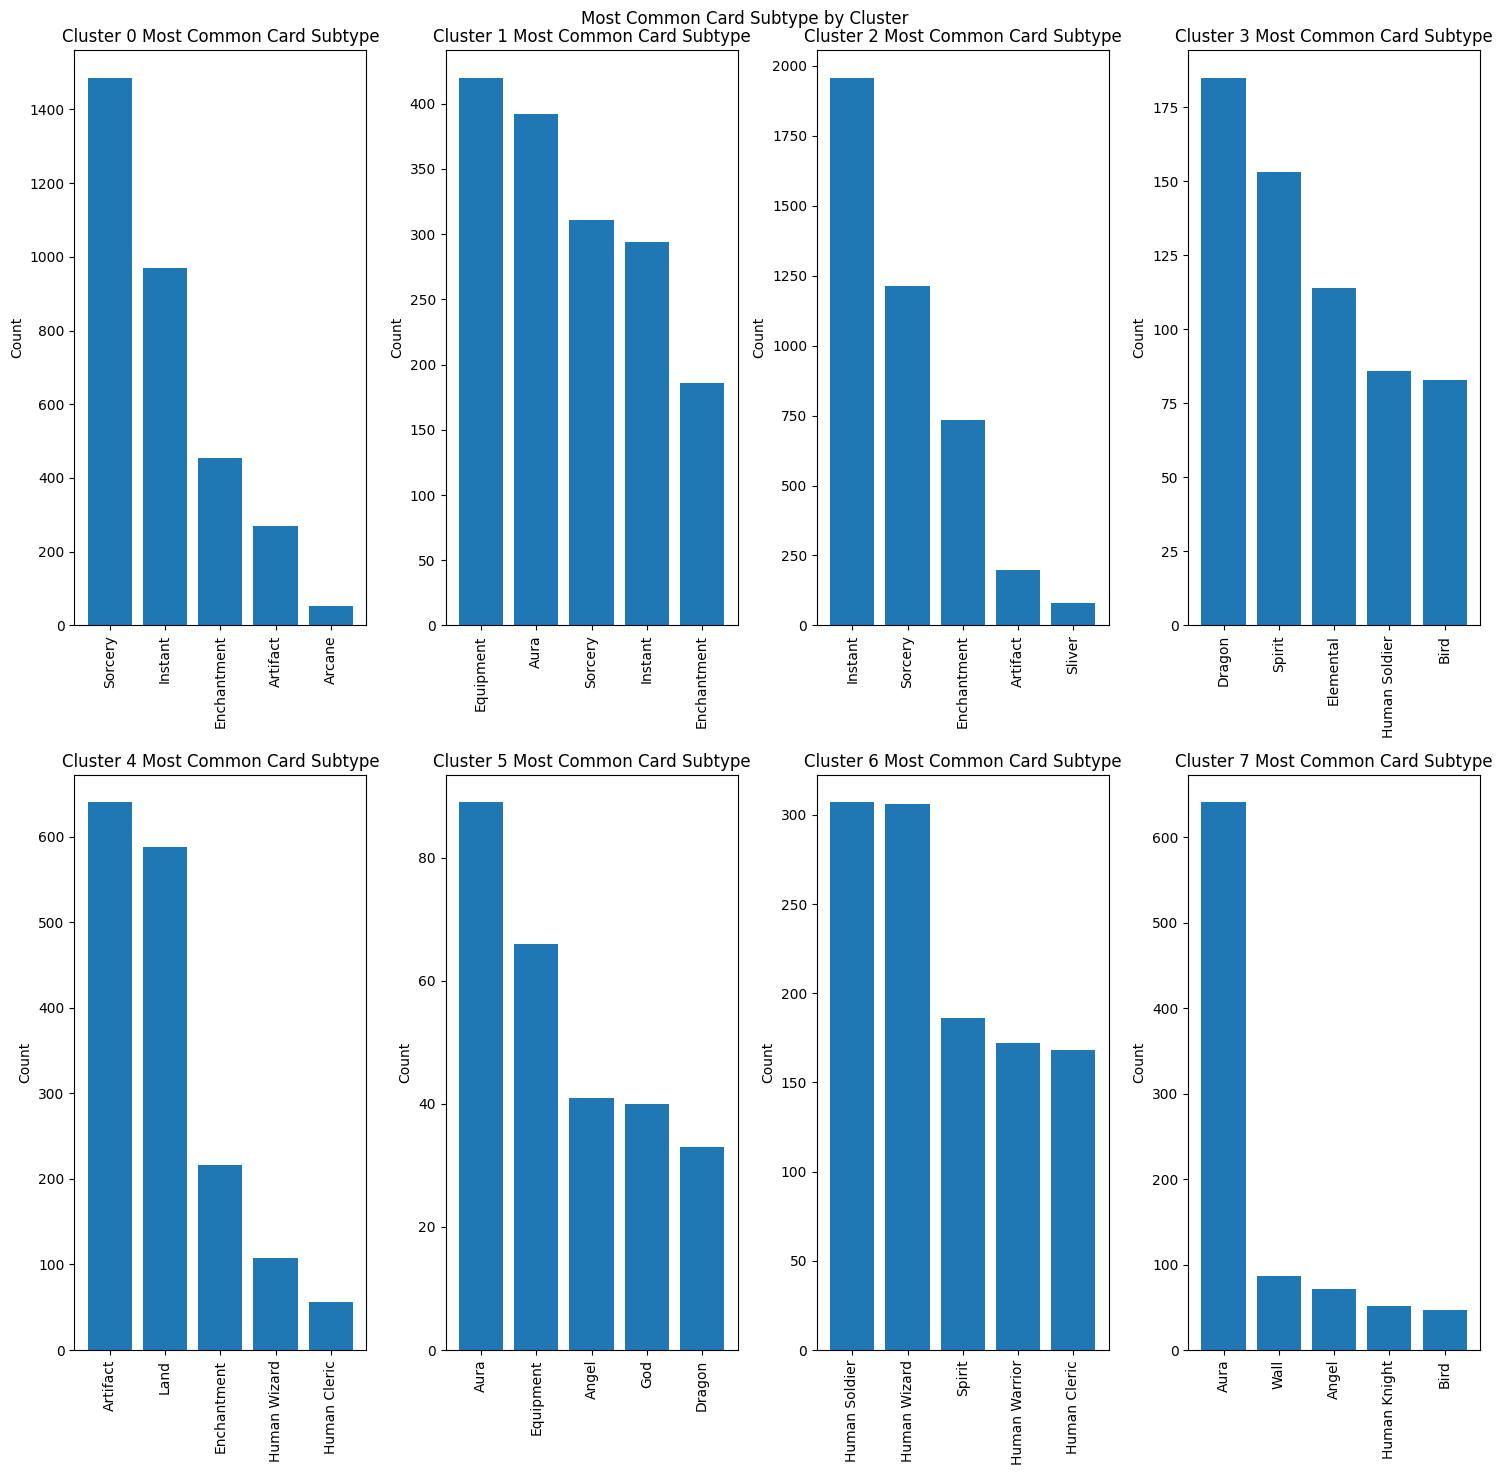

In [11]:
card_training_model.plot_card_subtype_clusters()

## TSNE Visualization

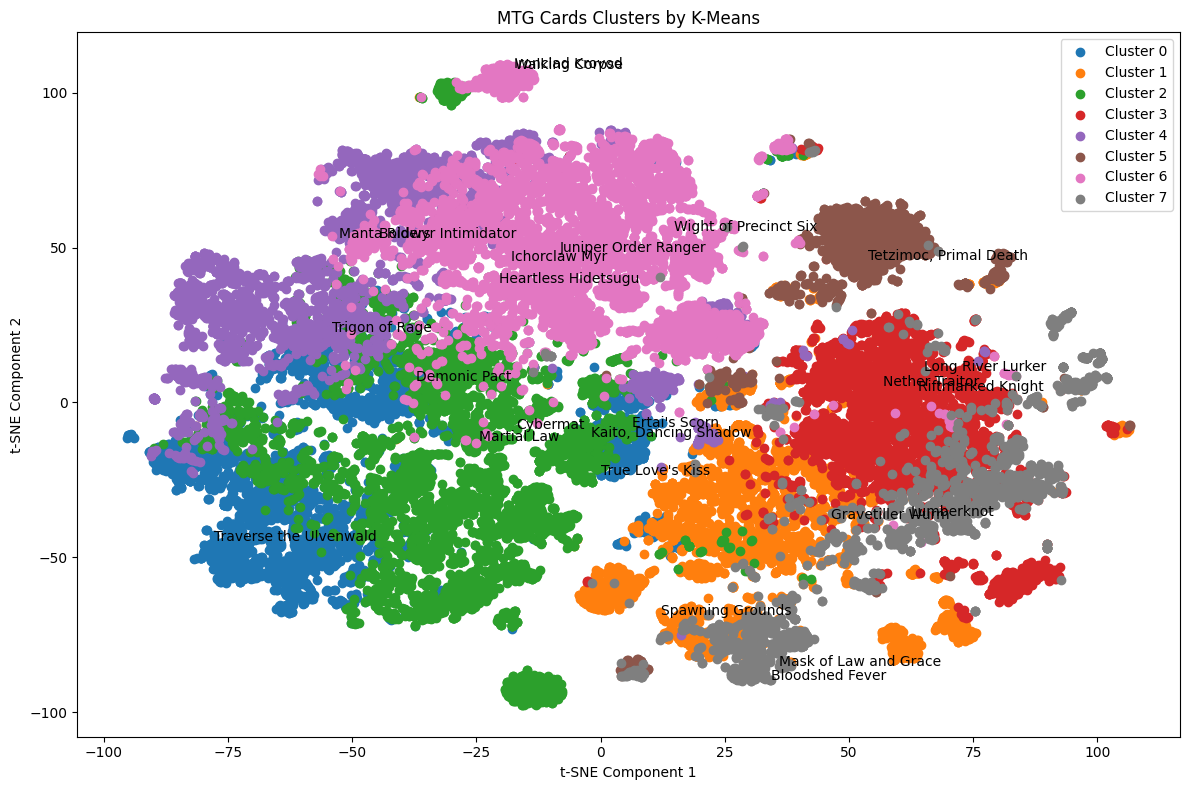

In [12]:
card_training_model.tsne_data_visualization()

## Cluster Feature Importance

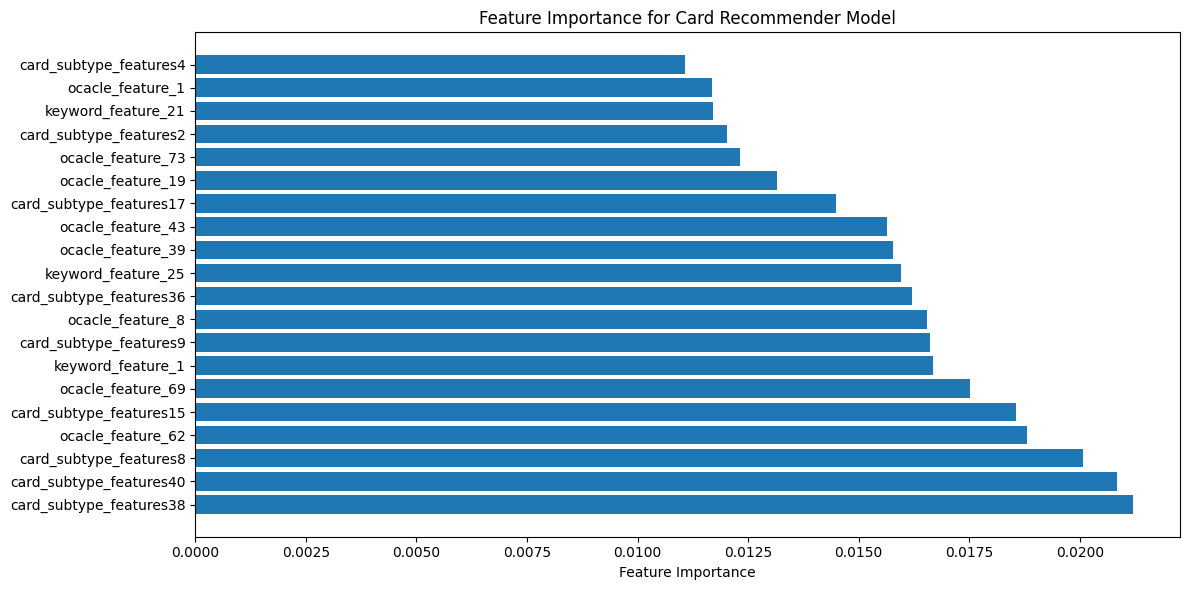

In [13]:
card_training_model.random_forest_feature_importance_visualization()

## Let's see our recommender model work

### Brainstorm
https://scryfall.com/card/dsc/113/brainstorm

In [14]:
card_training_model.find_nearest_neighbor_unscaled("Brainstorm")


Input Card: Brainstorm

Card Type: Instant

Mana Cost: U

Oracle Text: Draw three cards, then put two cards from your hand on top of your library in any order.

RECOMMENDED CARDS

Recommended Card 1: Giggling Skitterspike

Card Type 1: Artifact Creature

Mana Cost: 1: 4

Oracle Text: 1: Indestructible
Whenever this creature attacks, blocks, or becomes the target of a spell, it deals damage equal to its power to each opponent.
{5}: Monstrosity 5. (If this creature isn't monstrous, put five +1/+1 counters on it and it becomes monstrous.)


Recommended Card 2: Squealing Devil

Card Type 2: Creature

Mana Cost: 2: 1R

Oracle Text: 2: Fear (This creature can't be blocked except by artifact creatures and/or black creatures.)
When this creature enters, you may pay {X}. If you do, target creature gets +X/+0 until end of turn.
When this creature enters, sacrifice it unless {B} was spent to cast it.


Recommended Card 3: Grey Knight Paragon

Card Type 3: Creature

Mana Cost: 3: 4W

Oracle Text:

In [15]:
card_training_model.find_nearest_neighbor_scaled("Brainstorm")


Input Card: Brainstorm

Card Type: Instant

Mana Cost: U

Oracle Text: Draw three cards, then put two cards from your hand on top of your library in any order.

RECOMMENDED CARDS

Recommended Card 1: Brainsurge

Card Type 1: Instant

Mana Cost: 1: 2U

Oracle Text: 1: Draw four cards, then put two cards from your hand on top of your library in any order.


Recommended Card 2: Dream Cache

Card Type 2: Sorcery

Mana Cost: 2: 2U

Oracle Text: 2: Draw three cards, then put two cards from your hand both on top of your library or both on the bottom of your library.


Recommended Card 3: Amass the Components

Card Type 3: Sorcery

Mana Cost: 3: 3U

Oracle Text: 3: Draw three cards, then put a card from your hand on the bottom of your library.


Recommended Card 4: Scattered Thoughts

Card Type 4: Instant

Mana Cost: 4: 3U

Oracle Text: 4: Look at the top four cards of your library. Put two of those cards into your hand and the rest into your graveyard.


Recommended Card 5: Omen

Card Type 5

### Dictate of Erebos
https://scryfall.com/card/jou/65/dictate-of-erebos

In [16]:
card_training_model.find_nearest_neighbor_unscaled("Dictate of Erebos")


Input Card: Dictate of Erebos

Card Type: Enchantment

Mana Cost: 3BB

Oracle Text: Flash
Whenever a creature you control dies, each opponent sacrifices a creature of their choice.

RECOMMENDED CARDS

Recommended Card 1: Iron-Craw Crusher

Card Type 1: Artifact Creature

Mana Cost: 1: 7

Oracle Text: 1: Prototype {2}{G}{G} — 2/5 (You may cast this spell with different mana cost, color, and size. It keeps its abilities and types.)
Whenever this creature attacks, target attacking creature gets +X/+0 until end of turn, where X is this creature's power.


Recommended Card 2: Ogre-Head Helm

Card Type 2: Artifact Creature

Mana Cost: 2: 1R

Oracle Text: 2: Equipped creature gets +2/+2.
Whenever this creature or equipped creature deals combat damage to a player, you may sacrifice it. If you do, discard your hand, then draw three cards.
Reconfigure {3} ({3}: Attach to target creature you control; or unattach from a creature. Reconfigure only as a sorcery. While attached, this isn't a creatur

In [17]:
card_training_model.find_nearest_neighbor_scaled("Dictate of Erebos")


Input Card: Dictate of Erebos

Card Type: Enchantment

Mana Cost: 3BB

Oracle Text: Flash
Whenever a creature you control dies, each opponent sacrifices a creature of their choice.

RECOMMENDED CARDS

Recommended Card 1: Butcher of Malakir

Card Type 1: Creature

Mana Cost: 1: 5BB

Oracle Text: 1: Flying
Whenever this creature or another creature you control dies, each opponent sacrifices a creature of their choice.


Recommended Card 2: Grave Pact

Card Type 2: Enchantment

Mana Cost: 2: 1BBB

Oracle Text: 2: Whenever a creature you control dies, each other player sacrifices a creature of their choice.


Recommended Card 3: Thraximundar

Card Type 3: Legendary Creature

Mana Cost: 3: 4UBR

Oracle Text: 3: Haste
Whenever Thraximundar attacks, defending player sacrifices a creature of their choice.
Whenever a player sacrifices a creature, you may put a +1/+1 counter on Thraximundar.


Recommended Card 4: Hunted Nightmare

Card Type 4: Creature

Mana Cost: 4: 1BB

Oracle Text: 4: Menace

## The Shire
https://scryfall.com/card/fdn/223/giant-growth

In [20]:
card_training_model.find_nearest_neighbor_unscaled("Giant Growth")


Input Card: Giant Growth

Card Type: Instant

Mana Cost: G

Oracle Text: Target creature gets +3/+3 until end of turn.

RECOMMENDED CARDS

Recommended Card 1: Sokenzan Renegade

Card Type 1: Creature

Mana Cost: 1: 2R

Oracle Text: 1: Bushido 1 (Whenever this creature blocks or becomes blocked, it gets +1/+1 until end of turn.)
At the beginning of your upkeep, if a player has more cards in hand than each other player, the player who has the most cards in hand gains control of this creature.


Recommended Card 2: Hangar Scrounger

Card Type 2: Creature

Mana Cost: 2: 2R

Oracle Text: 2: Backup 1 (When this creature enters, put a +1/+1 counter on target creature. If that's another creature, it gains the following ability until end of turn.)
Whenever this creature becomes tapped, you may discard a card. If you do, draw a card.


Recommended Card 3: Acquisition Octopus

Card Type 3: Artifact Creature

Mana Cost: 3: 2U

Oracle Text: 3: Whenever this creature or equipped creature deals comb

In [21]:
card_training_model.find_nearest_neighbor_scaled("Giant Growth")


Input Card: Giant Growth

Card Type: Instant

Mana Cost: G

Oracle Text: Target creature gets +3/+3 until end of turn.

RECOMMENDED CARDS

Recommended Card 1: Titanic Growth

Card Type 1: Instant

Mana Cost: 1: 1G

Oracle Text: 1: Target creature gets +4/+4 until end of turn.


Recommended Card 2: Monstrous Growth

Card Type 2: Sorcery

Mana Cost: 2: 1G

Oracle Text: 2: Target creature gets +4/+4 until end of turn.


Recommended Card 3: Wielding the Green Dragon

Card Type 3: Sorcery

Mana Cost: 3: 1G

Oracle Text: 3: Target creature gets +4/+4 until end of turn.


Recommended Card 4: Phytoburst

Card Type 4: Sorcery

Mana Cost: 4: 1G

Oracle Text: 4: Target creature gets +5/+5 until end of turn.


Recommended Card 5: Bounty of Might

Card Type 5: Instant

Mana Cost: 5: 4GG

Oracle Text: 5: Target creature gets +3/+3 until end of turn.
Target creature gets +3/+3 until end of turn.
Target creature gets +3/+3 until end of turn.



## Krenko, Mob Boss
https://scryfall.com/card/fdn/204/krenko-mob-boss

In [22]:
card_training_model.find_nearest_neighbor_unscaled("Krenko, Mob Boss")


Input Card: Krenko, Mob Boss

Card Type: Legendary Creature

Mana Cost: 2RR

Oracle Text: {T}: Create X 1/1 red Goblin creature tokens, where X is the number of Goblins you control.

RECOMMENDED CARDS

Recommended Card 1: Skittering Crustacean

Card Type 1: Creature

Mana Cost: 1: 2U

Oracle Text: 1: {6}{U}: Monstrosity 4. (If this creature isn't monstrous, put four +1/+1 counters on it and it becomes monstrous.)
As long as this creature is monstrous, it has hexproof. (It can't be the target of spells or abilities your opponents control.)


Recommended Card 2: Fall of Cair Andros

Card Type 2: Enchantment

Mana Cost: 2: 2R

Oracle Text: 2: Whenever a creature an opponent controls is dealt excess noncombat damage, amass Orcs X, where X is that excess damage. (Put X +1/+1 counters on an Army you control. It's also an Orc. If you don't control an Army, create a 0/0 black Orc Army creature token first.)
{7}{R}: This enchantment deals 7 damage to target creature.


Recommended Card 3: Sque

In [23]:
card_training_model.find_nearest_neighbor_scaled("Krenko, Mob Boss")


Input Card: Krenko, Mob Boss

Card Type: Legendary Creature

Mana Cost: 2RR

Oracle Text: {T}: Create X 1/1 red Goblin creature tokens, where X is the number of Goblins you control.

RECOMMENDED CARDS

Recommended Card 1: Marrow-Gnawer

Card Type 1: Legendary Creature

Mana Cost: 1: 3BB

Oracle Text: 1: All Rats have fear.
{T}, Sacrifice a Rat: Create X 1/1 black Rat creature tokens, where X is the number of Rats you control.


Recommended Card 2: Horn of Gondor

Card Type 2: Legendary Artifact

Mana Cost: 2: 3

Oracle Text: 2: When Horn of Gondor enters, create a 1/1 white Human Soldier creature token.
{3}, {T}: Create X 1/1 white Human Soldier creature tokens, where X is the number of Humans you control.


Recommended Card 3: Snake Basket

Card Type 3: Artifact

Mana Cost: 3: 4

Oracle Text: 3: {X}, Sacrifice this artifact: Create X 1/1 green Snake creature tokens. Activate only as a sorcery.


Recommended Card 4: Emrakul's Evangel

Card Type 4: Creature

Mana Cost: 4: 2G

Oracle Te

## Wrath of God

In [24]:
card_training_model.find_nearest_neighbor_unscaled("Wrath of God")


Input Card: Wrath of God

Card Type: Sorcery

Mana Cost: 2WW

Oracle Text: Destroy all creatures. They can't be regenerated.

RECOMMENDED CARDS

Recommended Card 1: Cacophony Unleashed

Card Type 1: Enchantment

Mana Cost: 1: 5BB

Oracle Text: 1: When this enchantment enters, if you cast it, destroy all nonenchantment creatures.
Whenever this enchantment or another enchantment you control enters, until end of turn, this enchantment becomes a legendary 6/6 Nightmare God creature with menace and deathtouch. It's still an enchantment.


Recommended Card 2: Corpses of the Lost

Card Type 2: Enchantment

Mana Cost: 2: 2B

Oracle Text: 2: Skeletons you control get +1/+0 and have haste.
When this enchantment enters, create a 2/2 black Skeleton Pirate creature token.
At the beginning of your end step, if you descended this turn, you may pay 1 life. If you do, return this enchantment to its owner's hand. (You descended if a permanent card was put into your graveyard from anywhere.)


Recommend

In [25]:
card_training_model.find_nearest_neighbor_scaled("Wrath of God")


Input Card: Wrath of God

Card Type: Sorcery

Mana Cost: 2WW

Oracle Text: Destroy all creatures. They can't be regenerated.

RECOMMENDED CARDS

Recommended Card 1: Damnation

Card Type 1: Sorcery

Mana Cost: 1: 2BB

Oracle Text: 1: Destroy all creatures. They can't be regenerated.


Recommended Card 2: Plague Wind

Card Type 2: Sorcery

Mana Cost: 2: 7BB

Oracle Text: 2: Destroy all creatures you don't control. They can't be regenerated.


Recommended Card 3: Shatterstorm

Card Type 3: Sorcery

Mana Cost: 3: 2RR

Oracle Text: 3: Destroy all artifacts. They can't be regenerated.


Recommended Card 4: Winds of Rath

Card Type 4: Sorcery

Mana Cost: 4: 3WW

Oracle Text: 4: Destroy all creatures that aren't enchanted. They can't be regenerated.


Recommended Card 5: Perish

Card Type 5: Sorcery

Mana Cost: 5: 2B

Oracle Text: 5: Destroy all green creatures. They can't be regenerated.



In [26]:
card_training_model.find_nearest_neighbor_unscaled("Nekusar, the Mindrazer")


Input Card: Nekusar, the Mindrazer

Card Type: Legendary Creature

Mana Cost: 2UBR

Oracle Text: At the beginning of each player's draw step, that player draws an additional card.
Whenever an opponent draws a card, Nekusar deals 1 damage to that player.

RECOMMENDED CARDS

Recommended Card 1: Acquisition Octopus

Card Type 1: Artifact Creature

Mana Cost: 1: 2U

Oracle Text: 1: Whenever this creature or equipped creature deals combat damage to a player, draw a card.
Reconfigure {2} ({2}: Attach to target creature you control; or unattach from a creature. Reconfigure only as a sorcery. While attached, this isn't a creature.)


Recommended Card 2: Iron-Craw Crusher

Card Type 2: Artifact Creature

Mana Cost: 2: 7

Oracle Text: 2: Prototype {2}{G}{G} — 2/5 (You may cast this spell with different mana cost, color, and size. It keeps its abilities and types.)
Whenever this creature attacks, target attacking creature gets +X/+0 until end of turn, where X is this creature's power.


Recommen

In [27]:
card_training_model.find_nearest_neighbor_scaled("Nekusar, the Mindrazer")


Input Card: Nekusar, the Mindrazer

Card Type: Legendary Creature

Mana Cost: 2UBR

Oracle Text: At the beginning of each player's draw step, that player draws an additional card.
Whenever an opponent draws a card, Nekusar deals 1 damage to that player.

RECOMMENDED CARDS

Recommended Card 1: Spiteful Visions

Card Type 1: Enchantment

Mana Cost: 1: 2B/RB/R

Oracle Text: 1: At the beginning of each player's draw step, that player draws an additional card.
Whenever a player draws a card, this enchantment deals 1 damage to that player.


Recommended Card 2: Lavaborn Muse

Card Type 2: Creature

Mana Cost: 2: 3R

Oracle Text: 2: At the beginning of each opponent's upkeep, if that player has two or fewer cards in hand, this creature deals 3 damage to that player.


Recommended Card 3: Fevered Visions

Card Type 3: Enchantment

Mana Cost: 3: 1UR

Oracle Text: 3: At the beginning of each player's end step, that player draws a card. If the player is your opponent and has four or more cards i

In [28]:
card_training_model.find_nearest_neighbor_scaled("Emrakul, the Promised End")


Input Card: Emrakul, the Promised End

Card Type: Legendary Creature

Mana Cost: 13

Oracle Text: This spell costs {1} less to cast for each card type among cards in your graveyard.
When you cast this spell, you gain control of target opponent during that player's next turn. After that turn, that player takes an extra turn.
Flying, trample, protection from instants

RECOMMENDED CARDS

Recommended Card 1: Rakdos, the Muscle

Card Type 1: Legendary Creature

Mana Cost: 1: 2BBR

Oracle Text: 1: Flying, trample
Whenever you sacrifice another creature, exile cards equal to its mana value from the top of target player's library. Until your next end step, you may play those cards, and mana of any type can be spent to cast those spells.
Sacrifice another creature: Rakdos gains indestructible until end of turn. Tap it. Activate only once each turn.


Recommended Card 2: Mavinda, Students' Advocate

Card Type 2: Legendary Creature

Mana Cost: 2: 2W

Oracle Text: 2: Flying
{0}: You may cast targ